<a href="https://colab.research.google.com/github/brandonwooding/nlp-coursework/blob/main/COMP70016_NLP_bw725.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loading Data

In [1]:
from urllib import request
import pandas as pd

In [2]:
# Download data module
module_url = f"https://raw.githubusercontent.com/Perez-AlmendrosC/dontpatronizeme/master/semeval-2022/dont_patronize_me.py"
module_name = module_url.split('/')[-1]
print(f'Fetching {module_url}')
#with open("file_1.txt") as f1, open("file_2.txt") as f2
with request.urlopen(module_url) as f, open(module_name,'w') as outf:
  a = f.read()
  outf.write(a.decode('utf-8'))

Fetching https://raw.githubusercontent.com/Perez-AlmendrosC/dontpatronizeme/master/semeval-2022/dont_patronize_me.py


In [3]:
# helper function to save predictions to an output file
def labels2file(p, outf_path):
	with open(outf_path,'w') as outf:
		for pi in p:
			outf.write(','.join([str(k) for k in pi])+'\n')

In [4]:
from dont_patronize_me import DontPatronizeMe

In [5]:
dpm = DontPatronizeMe('.', '.')

In [6]:
# Load raw data
tsv_url = "https://raw.githubusercontent.com/CRLala/NLPLabs-2024/refs/heads/main/Dont_Patronize_Me_Trainingset/dontpatronizeme_pcl.tsv"
with request.urlopen(tsv_url) as f, open("dontpatronizeme_pcl.tsv", "w") as outf:
    outf.write(f.read().decode('utf-8'))

dpm.load_task1()


In [7]:
# Load the practice split CSVs
base = "https://raw.githubusercontent.com/Perez-AlmendrosC/dontpatronizeme/master/semeval-2022/practice%20splits/"

train_ids = pd.read_csv(base + "train_semeval_parids-labels.csv")
dev_ids = pd.read_csv(base + "dev_semeval_parids-labels.csv")

print(train_ids.shape, dev_ids.shape)
train_ids.head()

(8375, 2) (2094, 2)


,par_id,label
0,4341,"[1, 0, 0, 1, 0, 0, 0]"
1,4136,"[0, 1, 0, 0, 0, 0, 0]"
2,10352,"[1, 0, 0, 0, 0, 1, 0]"
3,8279,"[0, 0, 0, 1, 0, 0, 0]"
4,1164,"[1, 0, 0, 1, 1, 1, 0]"


In [8]:
train_ids.par_id = train_ids.par_id.astype(str)
dev_ids.par_id = dev_ids.par_id.astype(str)

In [9]:
data=dpm.train_task1_df
data

,par_id,art_id,keyword,country,text,label,orig_label
0,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0,0
1,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0,0
2,3,@@16584954,immigrant,ie,"""White House press secretary Sean Spicer said ...",0,0
3,4,@@7811231,disabled,nz,Council customers only signs would be displaye...,0,0
4,5,@@1494111,refugee,ca,""""""" Just like we received migrants fleeing El ...",0,0
...,...,...,...,...,...,...,...
10464,10465,@@14297363,women,lk,"""Sri Lankan norms and culture inhibit women fr...",0,1
10465,10466,@@70091353,vulnerable,ph,He added that the AFP will continue to bank on...,0,0
10466,10467,@@20282330,in-need,ng,""""""" She has one huge platform , and informatio...",1,3
10467,10468,@@16753236,hopeless,in,""""""" Anja Ringgren Loven I ca n't find a word t...",1,4


In [10]:
rows = [] # will contain par_id, label and text
for idx in range(len(train_ids)):
  parid = train_ids.par_id[idx]
  #print(parid)
  # select row from original dataset to retrieve `text` and binary label
  keyword = data.loc[data.par_id == parid].keyword.values[0]
  text = data.loc[data.par_id == parid].text.values[0]
  label = data.loc[data.par_id == parid].label.values[0]
  orig_label = data.loc[data.par_id == parid].orig_label.values[0]
  rows.append({
      'par_id':parid,
      'community':keyword,
      'text':text,
      'label':label,
      'original_label':orig_label
  })

  train_df = pd.DataFrame(rows)

In [11]:
rows = [] # will contain par_id, label and text
for idx in range(len(dev_ids)):
  parid = dev_ids.par_id[idx]
  #print(parid)
  # select row from original dataset
  keyword = data.loc[data.par_id == parid].keyword.values[0]
  text = data.loc[data.par_id == parid].text.values[0]
  label = data.loc[data.par_id == parid].label.values[0]
  orig_label = data.loc[data.par_id == parid].orig_label.values[0]
  rows.append({
      'par_id':parid,
      'community':keyword,
      'text':text,
      'label':label,
      'original_label':orig_label
  })

  dev_df = pd.DataFrame(rows)

In [12]:
from sklearn.utils import shuffle
data = shuffle(data, random_state=42)

train_df = shuffle(train_df, random_state=42)
dev_df = shuffle(dev_df, random_state=42)

In [13]:
dev_df.head()

,par_id,community,text,label,original_label
1712,10051,hopeless,"""Recent biographies on the Prince of Wales hav...",0,0
1344,9634,vulnerable,"AIRTEL Sales Officer for Lake Zone , Emmanuel ...",0,0
845,9097,immigrant,"Lehr said that , unlike today , where a Pole w...",0,0
275,8466,migrant,"""Trump infuriated Mexicans calling migrants fr...",0,0
29,2848,poor-families,Camfed would like to see this trend reversed ....,1,4


In [14]:
train_df['input_text'] = train_df['community'] + " : " + train_df['text']
dev_df['input_text'] = dev_df['community'] + " : " + dev_df['text']

# Exploratory Data Analysis

## Technique 1: Distributional Analysis of Class and Community

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

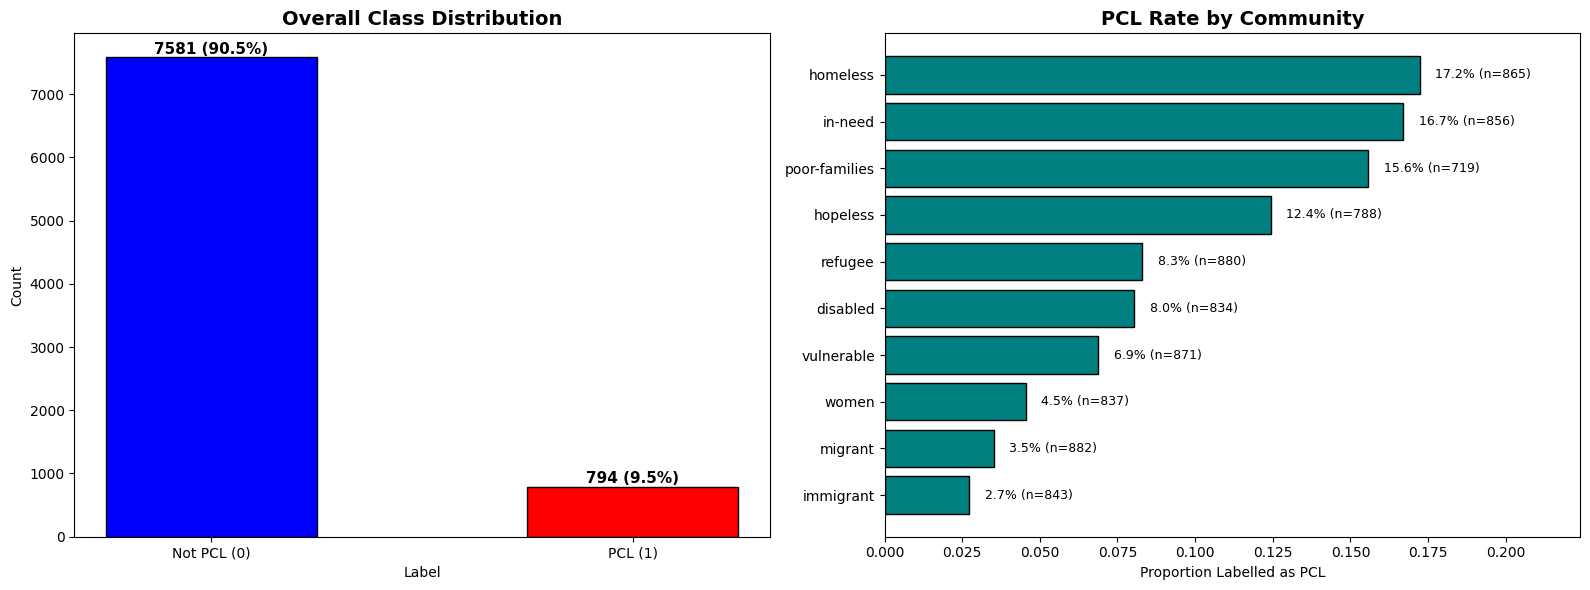


Imbalance ratio (non-PCL : PCL): 9.5 : 1
Minority class (PCL) is 9.5% of the data


In [16]:
# CLASS DISTRIBUTION

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

class_counts = train_df['label'].value_counts().sort_index()
colors = ['blue', 'red']
bars = axes[0].bar(class_counts.index.map({0: 'Not PCL (0)', 1: 'PCL (1)'}),
                   class_counts.values, color=colors, edgecolor='black', width=0.5)
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count} ({count/len(train_df)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Overall Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Label')

# PCL DISTRIBUTION BY COMMUNITY

community_stats = train_df.groupby('community')['label'].agg(['mean', 'count']).reset_index()
community_stats.columns = ['community', 'pcl_rate', 'total']
community_stats = community_stats.sort_values('pcl_rate', ascending=True)

bars = axes[1].barh(community_stats['community'], community_stats['pcl_rate'],
                     color='teal', edgecolor='black')
for bar, (_, row) in zip(bars, community_stats.iterrows()):
    axes[1].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{row["pcl_rate"]:.1%} (n={int(row["total"])})',
                 va='center', fontsize=9)
axes[1].set_title('PCL Rate by Community', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Proportion Labelled as PCL')
axes[1].set_xlim(0, community_stats['pcl_rate'].max() * 1.3)

plt.tight_layout()
plt.savefig('eda_technique1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary stats
imbalance_ratio = class_counts[0] / class_counts[1]
print(f"\nImbalance ratio (non-PCL : PCL): {imbalance_ratio:.1f} : 1")
print(f"Minority class (PCL) is {class_counts[1]/len(train_df)*100:.1f}% of the data")

## Technique 2: Lexical Comparison of Classes

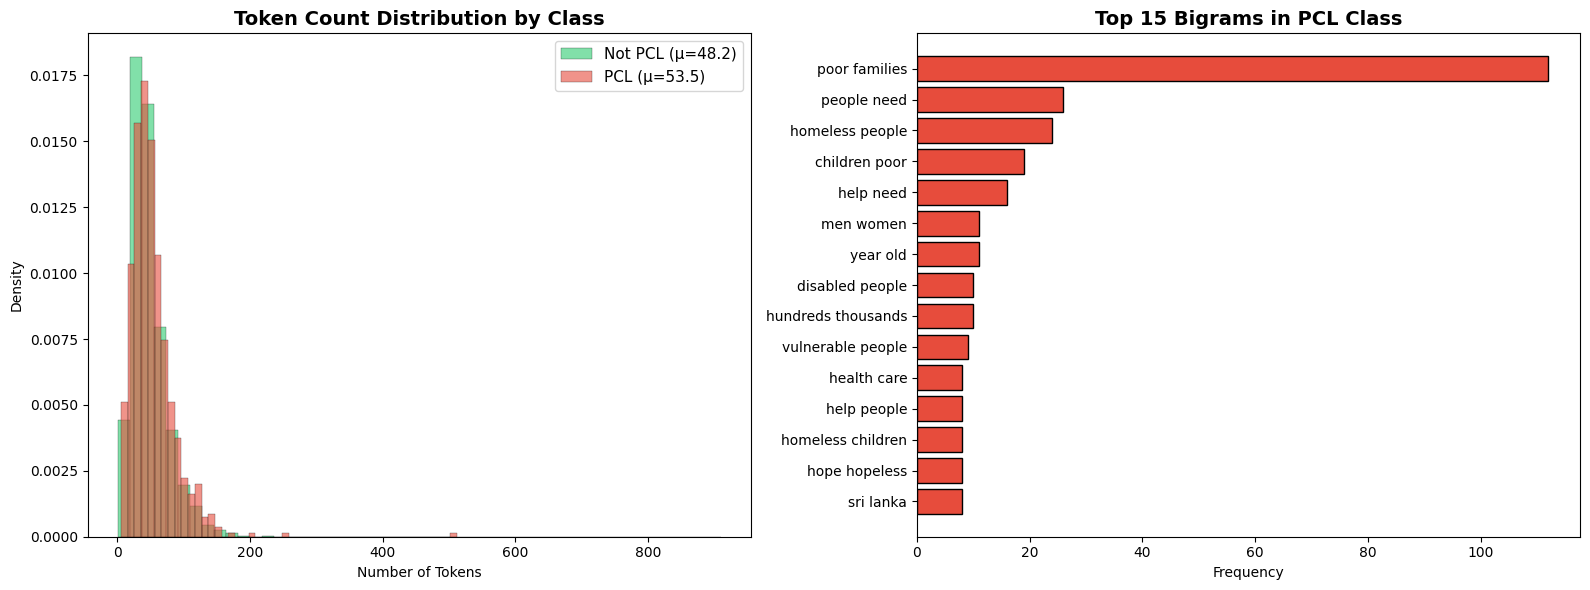

Token count statistics by class:
        count  mean   std  min   25%   50%   75%    max
label                                                  
0      7581.0  48.2  29.2  1.0  30.0  42.0  59.0  909.0
1       794.0  53.5  33.7  6.0  33.0  47.0  66.0  512.0


In [17]:
from sklearn.feature_extraction.text import CountVectorizer

# TOKEN COUNT
train_df['token_count'] = train_df['text'].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# TOKEN LENGHT DISTRIBUTION
for label, color, name in [(0, '#2ecc71', 'Not PCL'), (1, '#e74c3c', 'PCL')]:
    subset = train_df[train_df['label'] == label]['token_count']
    axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=f'{name} (μ={subset.mean():.1f})',
                 density=True, edgecolor='black', linewidth=0.3)
axes[0].set_title('Token Count Distribution by Class', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Tokens')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=11)

# DISCRIMINATIVE BIGRAMS
def get_top_ngrams(texts, n=2, top_k=15):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english', max_features=5000)
    X = vec.fit_transform(texts)
    freqs = zip(vec.get_feature_names_out(), X.sum(axis=0).A1)
    return sorted(freqs, key=lambda x: x[1], reverse=True)[:top_k]

pcl_texts = train_df[train_df['label'] == 1]['text']
non_pcl_texts = train_df[train_df['label'] == 0]['text']

pcl_bigrams = get_top_ngrams(pcl_texts, n=2, top_k=15)
labels_bg = [bg for bg, _ in pcl_bigrams]
values_bg = [v for _, v in pcl_bigrams]

axes[1].barh(labels_bg, values_bg, color='#e74c3c', edgecolor='black')
axes[1].set_title('Top 15 Bigrams in PCL Class', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('eda_technique2_lexical_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summmary stats
print("Token count statistics by class:")
print(train_df.groupby('label')['token_count'].describe().round(1))

# Individual Model Training

## Base Roberta

In [18]:
## TOKENIZER + ENCODINGS

from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained("roberta-base")


train_encodings = tokenizer(train_df['input_text'].tolist(), truncation=True, padding='max_length',
                            max_length=256, return_tensors='pt')
dev_encodings = tokenizer(dev_df['input_text'].tolist(), truncation=True, padding='max_length',
                           max_length=256, return_tensors='pt')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [19]:
## DATASETS

import torch
from torch.utils.data import Dataset, DataLoader

class PatronizeDataset(Dataset):
  def __init__(self, encodings, labels):
    self.encodings = encodings
    self.labels = torch.tensor(labels, dtype = torch.long)

  def __len__(self):
    return len(self.labels)

  def __getitem__(self, idx):
    item = {k: v[idx] for k, v in self.encodings.items()}
    item['labels'] = self.labels[idx]
    return item

train_dataset = PatronizeDataset(train_encodings, train_df['label'].tolist())
dev_dataset = PatronizeDataset(dev_encodings, dev_df['label'].tolist())

In [20]:
## MODEL

from transformers import RobertaForSequenceClassification, set_seed

set_seed(42)

model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [21]:
## METRICS + TRAINER

from transformers import Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

def compute_metrics(pred):
  logits, labels = pred
  if isinstance(labels, tuple):
        labels = labels[0]
  preds = np.argmax(logits, axis=-1)
  return {'f1': f1_score(labels, preds),
          'accuracy': accuracy_score(labels, preds)}

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=1e-5,
    weight_decay=0.01,
    fp16=True,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
)

base_trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    compute_metrics=compute_metrics
)

base_trainer.train()

Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.262395,0.208085,0.523659,0.927889
2,0.197997,0.227977,0.578313,0.916428
3,0.152254,0.247703,0.536585,0.927412
4,0.117577,0.302952,0.603406,0.922159
5,0.082047,0.352505,0.600509,0.925024


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2620, training_loss=0.15831871141914192, metrics={'train_runtime': 136.493, 'train_samples_per_second': 306.792, 'train_steps_per_second': 19.195, 'total_flos': 5508887721600000.0, 'train_loss': 0.15831871141914192, 'epoch': 5.0})

## Model Weighted on Class Distribution

In [22]:
# Check your actual class distribution first
neg_count = (train_df['label'] == 0).sum()
pos_count = (train_df['label'] == 1).sum()
ratio = neg_count / pos_count
print(ratio)  # use this to inform your weights

9.547858942065492


In [23]:
## No change to tokenizer, dataset, model or training args

## TRAINER

from torch import nn

set_seed(42)

class WeightedTrainer(Trainer):
  def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
    labels = inputs.pop('labels')
    outputs = model(**inputs)
    logits = outputs.logits
    # Cast the weight tensor to torch.float to match the logits dtype
    weight = torch.tensor([1.0,0.8 * ratio], dtype=torch.float).to(logits.device)
    loss_fn = nn.CrossEntropyLoss(weight=weight)
    loss = loss_fn(logits, labels)
    return(loss, outputs) if return_outputs else loss

weight_trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    compute_metrics=compute_metrics
)

weight_trainer.train()

Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.274633,1.180480,0.553991,0.909265
2,0.153902,1.175537,0.605150,0.912130
3,0.067197,1.288564,0.579775,0.910697
4,0.042187,1.515901,0.600985,0.922636
5,0.044616,1.622150,0.608040,0.925501


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2620, training_loss=0.1115304364502885, metrics={'train_runtime': 137.4667, 'train_samples_per_second': 304.619, 'train_steps_per_second': 19.059, 'total_flos': 5508887721600000.0, 'train_loss': 0.1115304364502885, 'epoch': 5.0})

## Soft Labels (weighted on original label)

In [24]:
## No change to tokenizer or model or training args

## DATSET

soft_map = {0: 0.0, 1: 0.15, 2: 0.65, 3: 0.85, 4: 1.0}
train_df['soft_label'] = train_df['original_label'].astype(int).map(soft_map)
dev_df['soft_label'] = dev_df['original_label'].astype(int).map(soft_map)

class SoftPatronizeDataset(Dataset):
  def __init__(self, encodings, labels):
    self.encodings = encodings
    self.labels = torch.tensor(labels, dtype = torch.float)

  def __len__(self):
    return len(self.labels)

  def __getitem__(self, idx):
    item = {k: v[idx] for k, v in self.encodings.items()}
    item['labels'] = self.labels[idx]
    return item

soft_train_dataset = SoftPatronizeDataset(train_encodings, train_df['soft_label'].values)
soft_dev_dataset = SoftPatronizeDataset(dev_encodings, dev_df['soft_label'].values)

In [25]:
## TRAINER

class SoftLabelTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits[:, 1]
        loss = nn.BCEWithLogitsLoss()(logits, labels)
        return (loss, outputs) if return_outputs else loss

def soft_compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.sigmoid(torch.tensor(logits[:, 1])).numpy()
    preds = (probs > 0.5).astype(int)
    binary_labels = (labels >= 0.5).astype(int)  # convert soft back to hard
    return {
        'f1': f1_score(binary_labels, preds),
        'accuracy': accuracy_score(binary_labels, preds)
    }

soft_label_trainer = SoftLabelTrainer(
    model=model,
    args=training_args,
    train_dataset=soft_train_dataset,
    eval_dataset=soft_dev_dataset,
    compute_metrics=soft_compute_metrics
)

soft_label_trainer.train()

Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.115633,0.260168,0.590717,0.907354
2,0.104363,0.228796,0.583120,0.922159
3,0.095830,0.225846,0.605042,0.932665
4,0.093326,0.243490,0.590258,0.931710
5,0.086351,0.238869,0.608939,0.933142


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2620, training_loss=0.09878468841086817, metrics={'train_runtime': 139.8211, 'train_samples_per_second': 299.49, 'train_steps_per_second': 18.738, 'total_flos': 5508887721600000.0, 'train_loss': 0.09878468841086817, 'epoch': 5.0})

## Multi-task model (with original labels in loss)

In [26]:
## No change to tokenizer

## DATASET

class MultiTaskDataset(Dataset):
    def __init__(self, encodings, binary_labels, severity_labels):
        self.encodings = encodings
        self.binary_labels = torch.tensor(binary_labels, dtype=torch.long)
        self.severity_labels = torch.tensor(severity_labels, dtype=torch.float)

    def __len__(self):
        return len(self.binary_labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.binary_labels[idx]
        item['severity_labels'] = self.severity_labels[idx]
        return item

multi_train_dataset = MultiTaskDataset(train_encodings, train_df['label'].values,
                                       train_df['original_label'].values.astype(float))
multi_dev_dataset = MultiTaskDataset(dev_encodings, dev_df['label'].values,
                                      dev_df['original_label'].values.astype(float))

In [27]:
## MODEL

from transformers import RobertaModel

class MultiTaskRoberta(nn.Module):
    def __init__(self):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained('roberta-base')
        self.dropout = nn.Dropout(0.1)
        # Two separate heads
        self.binary_head = nn.Linear(768, 2)       # binary classification
        self.severity_head = nn.Linear(768, 1)      # regression 0-4

    def forward(self, input_ids, attention_mask, labels=None, severity_labels=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.dropout(outputs.pooler_output)

        binary_logits = self.binary_head(pooled)
        severity_pred = self.severity_head(pooled).squeeze(-1)

        loss = None
        if labels is not None and severity_labels is not None:
            alpha = 0.7
            binary_loss = nn.CrossEntropyLoss()(binary_logits, labels)
            severity_loss = nn.MSELoss()(severity_pred, severity_labels)
            loss = alpha * binary_loss + (1 - alpha) * severity_loss

        return {'loss': loss, 'logits': binary_logits}

set_seed(42)
model = MultiTaskRoberta()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [28]:
## TRAINER

class MultiTaskTrainer(Trainer):
    def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
        labels = inputs.pop('labels')
        severity_labels = inputs.pop('severity_labels')

        with torch.no_grad():
            outputs = model(
                input_ids=inputs['input_ids'],
                attention_mask=inputs['attention_mask'],
                labels=labels,
                severity_labels=severity_labels
            )

        loss = outputs['loss']
        logits = outputs['logits']

        return (loss, logits, labels)  # only return binary labels

def multi_task_compute_metrics(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=-1)
    return {
        'f1': f1_score(labels, preds),
        'accuracy': accuracy_score(labels, preds)
    }

multi_training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=1e-5,
    weight_decay=0.01,
    label_names=['labels', 'severity_labels'],
    fp16=True,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
)

multi_task_trainer = MultiTaskTrainer(
    model=model,
    args=multi_training_args,
    train_dataset=multi_train_dataset,
    eval_dataset=multi_dev_dataset,
    compute_metrics=multi_task_compute_metrics
)

multi_task_trainer.train()

Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.404736,0.335513,0.416961,0.921203
2,0.297783,0.333821,0.580000,0.919771
3,0.223001,0.338139,0.509554,0.926457
4,0.178257,0.349748,0.594164,0.926934
5,0.130028,0.366804,0.578512,0.926934


TrainOutput(global_step=2620, training_loss=0.24115244232061256, metrics={'train_runtime': 137.5297, 'train_samples_per_second': 304.48, 'train_steps_per_second': 19.05, 'total_flos': 0.0, 'train_loss': 0.24115244232061256, 'epoch': 5.0})

## Ordinal

In [29]:
## No change to tokenizer, same training args from multi-task

## DATASET

class OrdinalDataset(Dataset):
    def __init__(self, encodings, orig_labels):
        self.encodings = encodings
        self.orig_labels = torch.tensor(orig_labels, dtype=torch.long)

    def __len__(self):
        return len(self.orig_labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.orig_labels[idx]
        return item

ordinal_train_dataset = OrdinalDataset(train_encodings, train_df['original_label'].values.astype(int))
ordinal_dev_dataset = OrdinalDataset(dev_encodings, dev_df['original_label'].values.astype(int))

In [30]:
## MODEL

class OrdinalRoberta(nn.Module):
    def __init__(self):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained('roberta-base')
        self.dropout = nn.Dropout(0.1)
        self.ordinal_head = nn.Linear(768, 4)  # P(>=1), P(>=2), P(>=3), P(>=4)

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.dropout(outputs.pooler_output)
        logits = self.ordinal_head(pooled)

        loss = None
        if labels is not None:
            # Convert orig_label to ordinal targets
            # e.g. orig_label=2 -> [1, 1, 0, 0]
            targets = torch.zeros_like(logits)
            for i in range(4):
                targets[:, i] = (labels > i).float()
            loss = nn.BCEWithLogitsLoss()(logits, targets)

        return {'loss': loss, 'logits': logits}

set_seed(42)

model = OrdinalRoberta()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [31]:
## TRAINER

class OrdinalTrainer(Trainer):
    def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
        labels = inputs.pop('labels')

        with torch.no_grad():
            outputs = model(
                input_ids=inputs['input_ids'],
                attention_mask=inputs['attention_mask'],
                labels=labels
            )

        loss = outputs['loss']
        logits = outputs['logits']

        # Convert orig_labels to binary for evaluation
        binary_labels = (labels >= 2).long()

        return (loss, logits, binary_labels)

def ordinal_compute_metrics(pred):
    logits, labels = pred
    probs = torch.sigmoid(torch.tensor(logits))
    binary_preds = (probs[:, 1] > 0.5).int().numpy()  # P(label >= 2)
    return {
        'f1': f1_score(labels, binary_preds),
        'accuracy': accuracy_score(labels, binary_preds)
    }

ordinal_trainer = OrdinalTrainer(
    model=model,
    args=multi_training_args,
    train_dataset=ordinal_train_dataset,
    eval_dataset=ordinal_dev_dataset,
    compute_metrics=ordinal_compute_metrics
)

ordinal_trainer.train()

Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.255220,0.203034,0.483871,0.923591
2,0.188758,0.195722,0.586735,0.922636
3,0.148776,0.199508,0.582210,0.925979
4,0.128261,0.217540,0.613402,0.928367
5,0.101484,0.222555,0.611702,0.930277


TrainOutput(global_step=2620, training_loss=0.1616101821870294, metrics={'train_runtime': 137.7755, 'train_samples_per_second': 303.936, 'train_steps_per_second': 19.016, 'total_flos': 0.0, 'train_loss': 0.1616101821870294, 'epoch': 5.0})

## DeBERTa

In [32]:
## TOKENIZER

from transformers import AutoTokenizer

deberta_tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-base')

deberta_train_encodings = deberta_tokenizer(
    train_df['input_text'].tolist(),
    truncation=True,
    padding='max_length',
    max_length=256,
    return_tensors='pt'
)

deberta_dev_encodings = deberta_tokenizer(
    dev_df['input_text'].tolist(),
    truncation=True,
    padding='max_length',
    max_length=256,
    return_tensors='pt'
)

config.json:   0%|          | 0.00/474 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

In [33]:
## DATASET

deberta_train_dataset = PatronizeDataset(deberta_train_encodings, train_df['label'].values)
deberta_dev_dataset = PatronizeDataset(deberta_dev_encodings, dev_df['label'].values)


In [34]:
## MODEL

from transformers import AutoModelForSequenceClassification

set_seed(44)

model = AutoModelForSequenceClassification.from_pretrained('microsoft/deberta-base', num_labels=2)

pytorch_model.bin:   0%|          | 0.00/559M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

DebertaForSequenceClassification LOAD REPORT from: microsoft/deberta-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/559M [00:00<?, ?B/s]

In [35]:

## No change to original compute metrics

## TRAINER

deberta_training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=1e-5,
    weight_decay=0.01,
    warmup_steps=500,
    max_grad_norm=1.0,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
)

deberta_base_trainer = Trainer(
    model=model,
    args=deberta_training_args,
    train_dataset=deberta_train_dataset,
    eval_dataset=deberta_dev_dataset,
    compute_metrics=compute_metrics
)

deberta_base_trainer.train()

Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.313120,0.204243,0.498534,0.918338
2,0.208136,0.194781,0.541436,0.920726
3,0.144136,0.230813,0.545977,0.924546
4,0.093304,0.311760,0.616505,0.924546
5,0.055257,0.350648,0.576087,0.925501


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2620, training_loss=0.15751185562774425, metrics={'train_runtime': 644.1862, 'train_samples_per_second': 65.004, 'train_steps_per_second': 4.067, 'total_flos': 6419387233920000.0, 'train_loss': 0.15751185562774425, 'epoch': 5.0})

# Ensemble Models

In [36]:
## Get predictions for dev set

from scipy.special import softmax

results_baseline = base_trainer.predict(dev_dataset)
results_weights = weight_trainer.predict(dev_dataset)
results_soft = soft_label_trainer.predict(soft_dev_dataset)
results_multi = multi_task_trainer.predict(multi_dev_dataset)
results_ordinal = ordinal_trainer.predict(ordinal_dev_dataset)
results_deberta = deberta_base_trainer.predict(deberta_dev_dataset)

# Convert logits to probabilities
prob_baseline = softmax(results_baseline.predictions, axis=1)[:, 1]
prob_weights = softmax(results_weights.predictions, axis=1)[:, 1]
prob_soft = softmax(results_soft.predictions, axis=1)[:, 1]
prob_multi = softmax(results_multi.predictions, axis=1)[:, 1]
prob_deberta = softmax(results_deberta.predictions, axis=1)[:, 1]

# Ordinal is different — use sigmoid on the second output
prob_ordinal = torch.sigmoid(torch.tensor(results_ordinal.predictions[:, 1])).numpy()

## Base ROBERTa with random seeds

## Average Ensemble with Threshold Tuning

In [37]:
avg_probs = (prob_baseline + prob_weights + prob_soft + prob_multi + prob_ordinal + prob_deberta) / 6
preds = (avg_probs > 0.5).astype(int)

true_labels = dev_df['label'].values
print("Ensemble F1:", f1_score(true_labels, preds))

Ensemble F1: 0.6270270270270271


In [38]:
best_f1 = 0
best_thresh = 0.5
for thresh in np.arange(0.2, 0.8, 0.01):
    preds = (avg_probs > thresh).astype(int)
    score = f1_score(true_labels, preds)
    if score > best_f1:
        best_f1 = score
        best_thresh = thresh

print(f"Best threshold: {best_thresh}, F1: {best_f1}")

Best threshold: 0.3000000000000001, F1: 0.6378896882494005


## Weighted Average by F1

In [39]:
f1_scores = {
    'baseline': f1_score(true_labels, (prob_baseline > 0.5).astype(int)),
    'soft': f1_score(true_labels, (prob_soft > 0.5).astype(int)),
    'multi': f1_score(true_labels, (prob_multi > 0.5).astype(int)),
    'ordinal': f1_score(true_labels, (prob_ordinal > 0.5).astype(int)),
    'deberta': f1_score(true_labels, (prob_deberta > 0.5).astype(int)),
}

total = sum(f1_scores.values())
weights = {k: v / total for k, v in f1_scores.items()}

weighted_probs = (
    weights['baseline'] * prob_baseline +
    weights['soft'] * prob_soft +
    weights['multi'] * prob_multi +
    weights['ordinal'] * prob_ordinal +
    weights['deberta'] * prob_deberta
)

preds = (weighted_probs > 0.5).astype(int)
print("Weighted F1:", f1_score(true_labels, preds))

Weighted F1: 0.6182795698924731


In [40]:
weighted_best_f1 = 0
weighted_best_thresh = 0.5
for thresh in np.arange(0.2, 0.8, 0.01):
    preds = (weighted_probs > thresh).astype(int)
    score = f1_score(true_labels, preds)
    if score > weighted_best_f1:
        weighted_best_f1 = score
        weighted_best_thresh = thresh

print(f"Best threshold: {weighted_best_thresh}, F1: {weighted_best_f1}")

Best threshold: 0.3200000000000001, F1: 0.6378896882494005


## Logistic Regression Ensemble

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Stack all probabilities as features
X_stack = np.column_stack([prob_baseline, prob_soft, prob_multi, prob_ordinal, prob_deberta])

# Use cross-validation to avoid overfitting the meta-learner
meta_model = LogisticRegression()
cv_scores = cross_val_score(meta_model, X_stack, true_labels, cv=5, scoring='f1')
print(f"Stacked F1 (CV): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Final fit
meta_model.fit(X_stack, true_labels)
print(list(zip(['baseline', 'weighted', 'soft', 'multi', 'ordinal', 'deberta'], meta_model.coef_[0])))


stacked_preds = meta_model.predict(X_stack)
print("Stacked F1:", f1_score(true_labels, stacked_preds))

Stacked F1 (CV): 0.5825 ± 0.0635
[('baseline', np.float64(0.8307754994803501)), ('weighted', np.float64(0.8307754994803501)), ('soft', np.float64(0.04941207957278787)), ('multi', np.float64(1.1445192753759483)), ('ordinal', np.float64(2.060243641954199))]
Stacked F1: 0.5868263473053892


In [42]:
results = {
    'Best single model': max(f1_scores.values()),
    'Simple average': f1_score(true_labels, (avg_probs > 0.5).astype(int)),
    'Tuned threshold': best_f1,
    'Weighted average': f1_score(true_labels, preds),
    'Stacked': f1_score(true_labels, stacked_preds),
}
for name, score in results.items():
    print(f"{name}: {score:.4f}")

Best single model: 0.6165
Simple average: 0.6270
Tuned threshold: 0.6379
Weighted average: 0.5687
Stacked: 0.5868


# Save Models

In [49]:
import json

# Standard HuggingFace models - save with trainer
base_trainer.save_model('./saved_models/baseline_roberta')
weight_trainer.save_model('./saved_models/weighted_roberta')
soft_label_trainer.save_model('./saved_models/soft_roberta')
deberta_base_trainer.save_model('./saved_models/deberta')

# Save tokenizers
deberta_tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-base')
roberta_tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

roberta_tokenizer.save_pretrained('./saved_models/baseline_roberta')
roberta_tokenizer.save_pretrained('./saved_models/weighted_roberta')
roberta_tokenizer.save_pretrained('./saved_models/soft_roberta')
deberta_tokenizer.save_pretrained('./saved_models/deberta')

# Custom architecture models - save with torch
torch.save(multi_task_trainer.model.state_dict(), './saved_models/multi_task_roberta.pt')
torch.save(ordinal_trainer.model.state_dict(), './saved_models/ordinal_roberta.pt')

# Ensemble config
ensemble_config = {
    'weights': weights,
    'threshold': best_thresh,
    'models': [
        'baseline_roberta',
        'weighted_roberta',
        'soft_roberta',
        'multi_task_roberta',
        'ordinal_roberta',
        'deberta'
    ]
}

with open('./saved_models/ensemble_config.json', 'w') as f:
    json.dump(ensemble_config, f)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [53]:
from google.colab import drive
drive.mount('/content/drive')

import os
# Create a specific directory for your models
drive_path = '/content/drive/MyDrive/pcl_models'
os.makedirs(drive_path, exist_ok=True)
print(f'Models will be saved to: {drive_path}')

Mounted at /content/drive
Models will be saved to: /content/drive/MyDrive/pcl_models


In [54]:
import json
import os

# Define the base path on Google Drive
save_base_path = '/content/drive/MyDrive/pcl_models'
os.makedirs(save_base_path, exist_ok=True)

# Standard HuggingFace models - save with trainer
base_trainer.save_model(os.path.join(save_base_path, 'baseline_roberta'))
weight_trainer.save_model(os.path.join(save_base_path, 'weighted_roberta'))
soft_label_trainer.save_model(os.path.join(save_base_path, 'soft_roberta'))
deberta_base_trainer.save_model(os.path.join(save_base_path, 'deberta'))

# Save tokenizers
deberta_tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-base')
roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

roberta_tokenizer.save_pretrained(os.path.join(save_base_path, 'baseline_roberta'))
roberta_tokenizer.save_pretrained(os.path.join(save_base_path, 'weighted_roberta'))
roberta_tokenizer.save_pretrained(os.path.join(save_base_path, 'soft_roberta'))
deberta_tokenizer.save_pretrained(os.path.join(save_base_path, 'deberta'))

# Custom architecture models - save with torch
torch.save(multi_task_trainer.model.state_dict(), os.path.join(save_base_path, 'multi_task_roberta.pt'))
torch.save(ordinal_trainer.model.state_dict(), os.path.join(save_base_path, 'ordinal_roberta.pt'))

# Ensemble config
ensemble_config = {
    'weights': weights,
    'threshold': best_thresh,
    'models': [
        'baseline_roberta',
        'weighted_roberta',
        'soft_roberta',
        'multi_task_roberta',
        'ordinal_roberta',
        'deberta'
    ]
}

with open(os.path.join(save_base_path, 'ensemble_config.json'), 'w') as f:
    json.dump(ensemble_config, f)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [50]:
from huggingface_hub import login
login()

In [52]:
# Baseline RoBERTa
base_trainer.model.push_to_hub('brandonwooding/patronize-baseline-roberta')
roberta_tokenizer.push_to_hub('brandonwooding/patronize-baseline-roberta')

# Weighted RoBERTa
weight_trainer.model.push_to_hub('brandonwooding/patronize-weighted-roberta')
roberta_tokenizer.push_to_hub('brandonwooding/patronize-weighted-roberta')

# Soft Label RoBERTa
soft_label_trainer.model.push_to_hub('brandonwooding/patronize-soft-roberta')
roberta_tokenizer.push_to_hub('brandonwooding/patronize-soft-roberta')

# Baseline DeBERTa
deberta_base_trainer.model.push_to_hub('brandonwooding/patronize-baseline-deberta')
deberta_tokenizer.push_to_hub('brandonwooding/patronize-baseline-deberta')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...x8ik8fc/model.safetensors:   1%|1         | 7.16MB /  499MB            

README.md: 0.00B [00:00, ?B/s]

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...lxjfh7o/model.safetensors:   1%|          | 3.89MB /  557MB            

README.md: 0.00B [00:00, ?B/s]

CommitInfo(commit_url='https://huggingface.co/brandonwooding/patronize-baseline-deberta/commit/ef49b37a55a0c621e7568d7e6818642ba37cb9d6', commit_message='Upload tokenizer', commit_description='', oid='ef49b37a55a0c621e7568d7e6818642ba37cb9d6', pr_url=None, repo_url=RepoUrl('https://huggingface.co/brandonwooding/patronize-baseline-deberta', endpoint='https://huggingface.co', repo_type='model', repo_id='brandonwooding/patronize-baseline-deberta'), pr_revision=None, pr_num=None)

In [55]:
from huggingface_hub import HfApi
api = HfApi()

# Multi-task RoBERTa
api.create_repo('brandonwooding/patronize-multitask-roberta', exist_ok=True)
api.upload_file(
    path_or_fileobj='./saved_models/multi_task_roberta.pt',
    path_in_repo='multi_task_roberta.pt',
    repo_id='brandonwooding/patronize-multitask-roberta'
)

# Ordinal RoBERTa
api.create_repo('brandonwooding/patronize-ordinal-roberta', exist_ok=True)
api.upload_file(
    path_or_fileobj='./saved_models/ordinal_roberta.pt',
    path_in_repo='ordinal_roberta.pt',
    repo_id='brandonwooding/patronize-ordinal-roberta'
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...els/multi_task_roberta.pt:   2%|1         | 9.34MB /  499MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...models/ordinal_roberta.pt:   1%|          | 3.85MB /  499MB            

CommitInfo(commit_url='https://huggingface.co/brandonwooding/patronize-ordinal-roberta/commit/a9122111398659efbbfc4c72e039e5debe6c7fcf', commit_message='Upload ordinal_roberta.pt with huggingface_hub', commit_description='', oid='a9122111398659efbbfc4c72e039e5debe6c7fcf', pr_url=None, repo_url=RepoUrl('https://huggingface.co/brandonwooding/patronize-ordinal-roberta', endpoint='https://huggingface.co', repo_type='model', repo_id='brandonwooding/patronize-ordinal-roberta'), pr_revision=None, pr_num=None)